# 📊 9-dars: Korrelyatsiya va Regressiya Asoslari

## 🎯 Dars maqsadi
Ushbu darsda biz o'zgaruvchilar orasidagi bog'lanishni o'rganamiz:
- **Korrelyatsiya** - ikki o'zgaruvchi qanchalik bog'liqligini o'lchash
- **Regressiya** - bir o'zgaruvchi asosida boshqasini bashorat qilish

## 📋 Dars rejasi
1. **Korrelyatsiya asoslari**
   - Pearson korrelyatsiyasi
   - Spearman korrelyatsiyasi
2. **Oddiy chiziqli regressiya**
   - Regressiya chizig'i
   - Model baholash
3. **Amaliy misollar**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 📊 1. KORRELYATSIYA ASOSLARI

### 🤔 Korrelyatsiya nima?
**Korrelyatsiya** - ikki o'zgaruvchi orasidagi chiziqli bog'lanish kuchini va yo'nalishini o'lchaydigan statistik ko'rsatkich.

### 📈 Korrelyatsiya turlari:
- **Ijobiy korrelyatsiya (+)**: Bir o'zgaruvchi ortsa, ikkinchisi ham ortadi
- **Salbiy korrelyatsiya (-)**: Bir o'zgaruvchi ortsa, ikkinchisi kamayadi  
- **Nol korrelyatsiya (0)**: O'zgaruvchilar orasida chiziqli bog'lanish yo'q

### 🎯 Korrelyatsiya koeffitsiyenti qiymatlari:
- **+1**: Mukammal ijobiy bog'lanish
- **+0.7 dan +0.9**: Kuchli ijobiy bog'lanish
- **+0.3 dan +0.7**: O'rtacha ijobiy bog'lanish
- **-0.3 dan +0.3**: Zaif yoki bog'lanish yo'q
- **-0.3 dan -0.7**: O'rtacha salbiy bog'lanish
- **-0.7 dan -0.9**: Kuchli salbiy bog'lanish
- **-1**: Mukammal salbiy bog'lanish

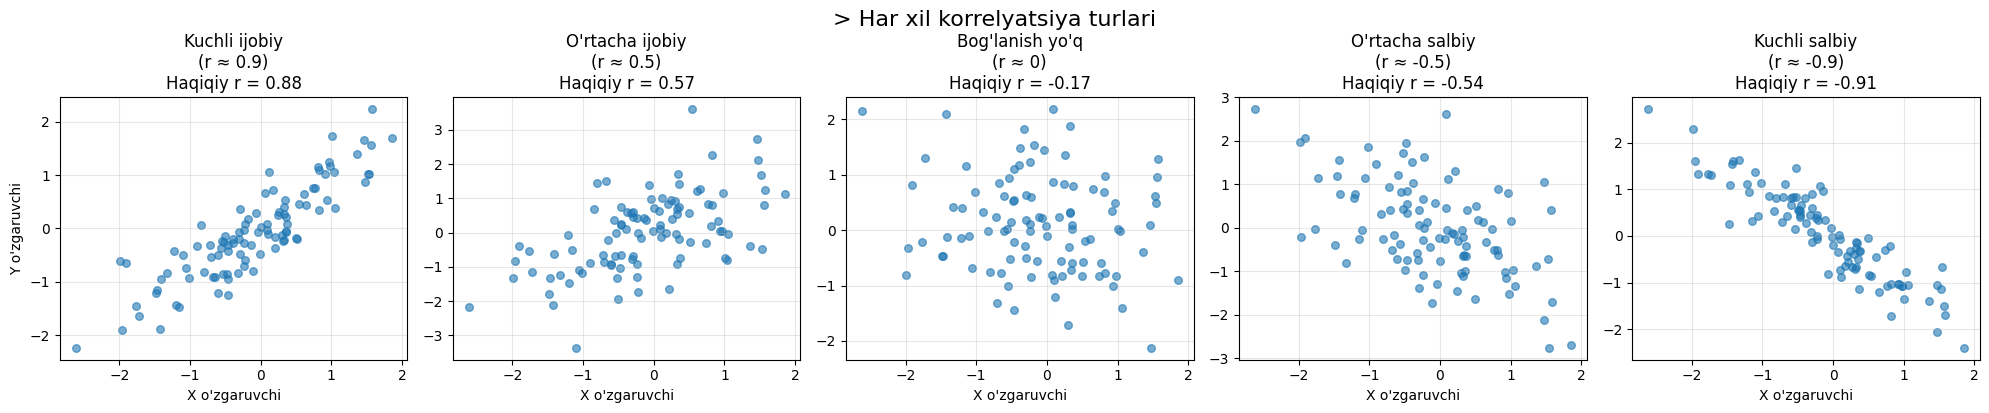

In [3]:
# Korrelyatsiya turlarini vizualizatsiya qilish
np.random.seed(42)

# Har xil korrelyatsiya bilan ma'lumotlar yaratish
x = np.random.randn(100)

# Har xil korrelyatsiya koeffitsiyentlari
correlations = [0.9, 0.5, 0, -0.5, -0.9]
titles = ['Kuchli ijobiy\n(r ≈ 0.9)', 'O\'rtacha ijobiy\n(r ≈ 0.5)', 
          'Bog\'lanish yo\'q\n(r ≈ 0)', 'O\'rtacha salbiy\n(r ≈ -0.5)', 
          'Kuchli salbiy\n(r ≈ -0.9)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (corr, title) in enumerate(zip(correlations, titles)):
    # Berilgan korrelyatsiya bilan y yaratish
    noise = np.random.randn(100) * np.sqrt(1 - corr**2)
    y = corr * x + noise
    
    # Haqiqiy korrelyatsiyani hisoblash
    actual_corr = np.corrcoef(x, y)[0, 1]
    
    axes[i].scatter(x, y, alpha=0.6, s=30)
    axes[i].set_title(f'{title}\nHaqiqiy r = {actual_corr:.2f}')
    axes[i].set_xlabel('X o\'zgaruvchi')
    if i == 0:
        axes[i].set_ylabel('Y o\'zgaruvchi')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('> Har xil korrelyatsiya turlari', fontsize=16, y=1.02)
plt.show()

## 📊 2. PEARSON KORRELYATSIYA KOEFFITSIYENTI

### 🧮 Formula:
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

### 📋 Xususiyatlari:
- Faqat **chiziqli bog'lanishni** o'lchaydi
- Ma'lumotlar **normal taqsimotga** yaqin bo'lishi kerak
- **Parametrik** usul
- Eng ko'p qo'llaniladigan korrelyatsiya turi

In [4]:
students_data = pd.read_csv('datasets/students_math.csv')
students_data.head()

,student_id,study_hours,math_score,physics_score,height_cm,weight_kg,sleep_hours,caffeine_cups
0,1,2.5,65,70,165,55,7,1
1,2,4.0,78,82,170,62,8,2
2,3,1.5,45,50,160,48,6,0
3,4,6.0,92,88,175,68,7,3
4,5,3.0,70,75,168,58,8,1


In [5]:
print(f"\n📈 Ma'lumotlar o'lchami: {students_data.shape}")
print(f"\n📋 Ustunlar: {list(students_data.columns)}")


📈 Ma'lumotlar o'lchami: (50, 8)

📋 Ustunlar: ['student_id', 'study_hours', 'math_score', 'physics_score', 'height_cm', 'weight_kg', 'sleep_hours', 'caffeine_cups']


📊 O'qish soatlari va Matematika bali:
   🔢 Pearson korrelyatsiya: 0.961
   📈 P-qiymat: 0.000
   ✅ Statistik ahamiyat: Ha


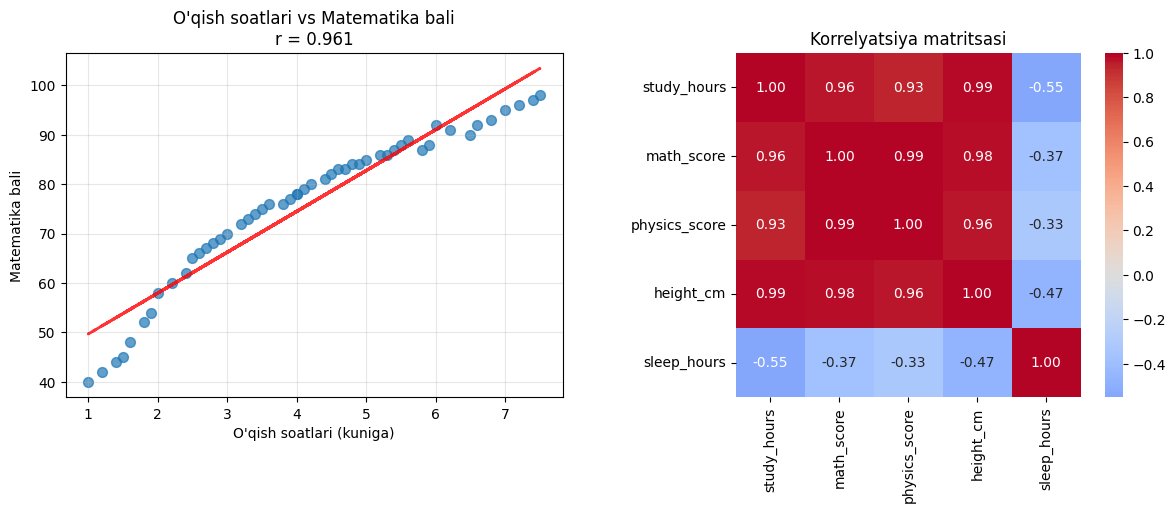

In [6]:
# O'qish soatlari va matematika bali o'rtasidagi korrelyatsiya
study_hours = students_data['study_hours']
math_score = students_data['math_score']

# Pearson korrelyatsiyasini hisoblash
pearson_corr, p_value = stats.pearsonr(study_hours, math_score)

print(f"📊 O'qish soatlari va Matematika bali:")
print(f"   🔢 Pearson korrelyatsiya: {pearson_corr:.3f}")
print(f"   📈 P-qiymat: {p_value:.3f}")
print(f"   ✅ Statistik ahamiyat: {'Ha' if p_value < 0.05 else 'Yo\'q'}")

# Vizualizatsiya
plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(study_hours, math_score, alpha=0.7, s=50)
plt.xlabel('O\'qish soatlari (kuniga)')
plt.ylabel('Matematika bali')
plt.title(f'O\'qish soatlari vs Matematika bali\nr = {pearson_corr:.3f}')
plt.grid(True, alpha=0.3)

# Regressiya chizig'i qo'shish
z = np.polyfit(study_hours, math_score, 1)
p = np.poly1d(z)
plt.plot(study_hours, p(study_hours), "r--", alpha=0.8, linewidth=2)

# Korrelyatsiya matritsasi
plt.subplot(1, 2, 2)
numeric_cols = ['study_hours', 'math_score', 'physics_score', 'height_cm', 'sleep_hours']
corr_matrix = students_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Korrelyatsiya matritsasi')

plt.tight_layout()
plt.show()

In [7]:
# Qo'lda Pearson korrelyatsiyasini hisoblash
print("🧮 QO'LDA PEARSON KORRELYATSIYASINI HISOBLASH:")
print("=" * 50)

# Ma'lumotlarni tayyorlash
x = study_hours
y = math_score
n = len(x)

# O'rtacha qiymatlar
x_mean = np.mean(x)
y_mean = np.mean(y)

print(f"📊 Asosiy statistikalar:")
print(f"   n = {n}")
print(f"   x̄ (o'qish soatlari o'rtacha) = {x_mean:.2f}")
print(f"   ȳ (matematika bali o'rtacha) = {y_mean:.2f}")

# Formulaning qismlari
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator_x = np.sum((x - x_mean)**2)
denominator_y = np.sum((y - y_mean)**2)
denominator = np.sqrt(denominator_x * denominator_y)

# Korrelyatsiya koeffitsiyenti
r_manual = numerator / denominator

print(f"\n🧮 Formula qismlari:")
print(f"   Numerator = Σ(xi - x̄)(yi - ȳ) = {numerator:.2f}")
print(f"   Denominator = √[Σ(xi - x̄)² × Σ(yi - ȳ)²] = {denominator:.2f}")
print(f"   r = {numerator:.2f} / {denominator:.2f} = {r_manual:.3f}")

print(f"\n✅ Tekshirish:")
print(f"   Qo'lda hisoblangan: {r_manual:.3f}")
print(f"   Python funksiyasi: {pearson_corr:.3f}")
print(f"   Farq: {abs(r_manual - pearson_corr):.6f}")

🧮 QO'LDA PEARSON KORRELYATSIYASINI HISOBLASH:
📊 Asosiy statistikalar:
   n = 50
   x̄ (o'qish soatlari o'rtacha) = 4.15
   ȳ (matematika bali o'rtacha) = 75.70

🧮 Formula qismlari:
   Numerator = Σ(xi - x̄)(yi - ȳ) = 1310.09
   Denominator = √[Σ(xi - x̄)² × Σ(yi - ȳ)²] = 1363.58
   r = 1310.09 / 1363.58 = 0.961

✅ Tekshirish:
   Qo'lda hisoblangan: 0.961
   Python funksiyasi: 0.961
   Farq: 0.000000


## 📊 3. SPEARMAN KORRELYATSIYA KOEFFITSIYENTI

### 🧮 Formula:
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

Bu yerda $d_i$ - i-elementning x va y o'zgaruvchilardagi ranklari orasidagi farq.

### 📋 Xususiyatlari:
- **Monoton bog'lanishni** o'lchaydi (chiziqli bo'lishi shart emas)
- **Noparametrik** usul
- **Ranklar** bilan ishlaydi
- Normal taqsimot talab qilmaydi
- **Outlier**larga kam ta'sir qiladi

In [8]:
# Spearman korrelyatsiyasini hisoblash
spearman_corr, spearman_p = stats.spearmanr(study_hours, math_score)

print(f"📊 PEARSON vs SPEARMAN TAQQOSLASH:")
print("=" * 50)
print(f"   🔢 Pearson korrelyatsiya:  {pearson_corr:.3f}")
print(f"   📈 Spearman korrelyatsiya: {spearman_corr:.3f}")
print(f"   📊 Farq: {abs(pearson_corr - spearman_corr):.3f}")

# Qo'lda Spearman korrelyatsiyasini hisoblash
print(f"\n🧮 QO'LDA SPEARMAN HISOBLASH:")
print("=" * 30)

# Ranklarni hisoblash
x_ranks = stats.rankdata(study_hours)
y_ranks = stats.rankdata(math_score)

# Rank farqlari
d = x_ranks - y_ranks
d_squared = d**2
sum_d_squared = np.sum(d_squared)

# Spearman formulasi
n = len(study_hours)
spearman_manual = 1 - (6 * sum_d_squared) / (n * (n**2 - 1))

print(f"   n = {n}")
print(f"   Σd² = {sum_d_squared:.2f}")
print(f"   ρ = 1 - (6 × {sum_d_squared:.2f}) / ({n} × ({n}² - 1))")
print(f"   ρ = {spearman_manual:.3f}")
print(f"\n✅ Python natijasi: {spearman_corr:.3f}")

📊 PEARSON vs SPEARMAN TAQQOSLASH:
   🔢 Pearson korrelyatsiya:  0.961
   📈 Spearman korrelyatsiya: 0.999
   📊 Farq: 0.038

🧮 QO'LDA SPEARMAN HISOBLASH:
   n = 50
   Σd² = 27.50
   ρ = 1 - (6 × 27.50) / (50 × (50² - 1))
   ρ = 0.999

✅ Python natijasi: 0.999


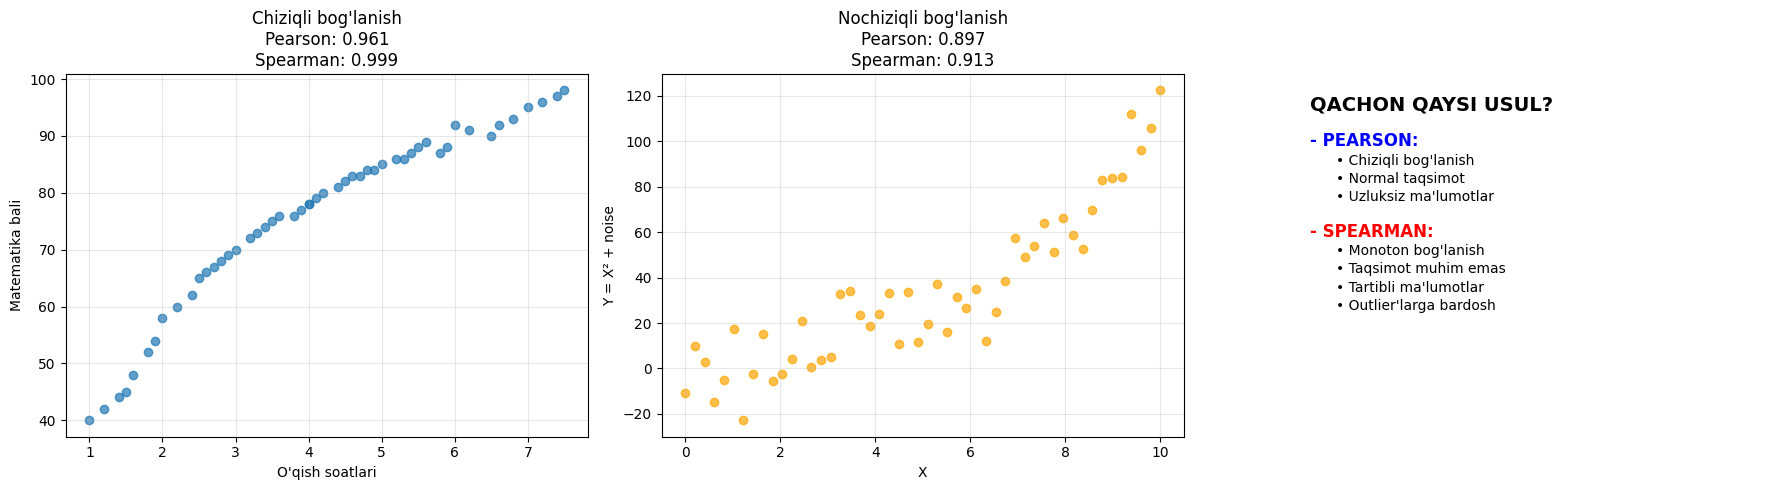

In [9]:
# Pearson vs Spearman farqini ko'rsatish uchun nochiziqli ma'lumot yaratish
np.random.seed(123)
x_nonlinear = np.linspace(0, 10, 50)
y_nonlinear = x_nonlinear**2 + np.random.normal(0, 10, 50)  # Kvadratik bog'lanish

# Korrelyatsiyalarni hisoblash
pearson_nl = stats.pearsonr(x_nonlinear, y_nonlinear)[0]
spearman_nl = stats.spearmanr(x_nonlinear, y_nonlinear)[0]

# Vizualizatsiya
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Chiziqli bog'lanish
axes[0].scatter(study_hours, math_score, alpha=0.7)
axes[0].set_title(f'Chiziqli bog\'lanish\nPearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}')
axes[0].set_xlabel('O\'qish soatlari')
axes[0].set_ylabel('Matematika bali')
axes[0].grid(True, alpha=0.3)

# 2. Nochiziqli bog'lanish
axes[1].scatter(x_nonlinear, y_nonlinear, alpha=0.7, color='orange')
axes[1].set_title(f'Nochiziqli bog\'lanish\nPearson: {pearson_nl:.3f}\nSpearman: {spearman_nl:.3f}')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y = X² + noise')
axes[1].grid(True, alpha=0.3)

# 3. Qachon qaysi usulni ishlatish
axes[2].text(0.1, 0.9, 'QACHON QAYSI USUL?', fontsize=14, fontweight='bold', transform=axes[2].transAxes)
axes[2].text(0.1, 0.8, '- PEARSON:', fontsize=12, fontweight='bold', color='blue', transform=axes[2].transAxes)
axes[2].text(0.15, 0.75, '• Chiziqli bog\'lanish', fontsize=10, transform=axes[2].transAxes)
axes[2].text(0.15, 0.7, '• Normal taqsimot', fontsize=10, transform=axes[2].transAxes)
axes[2].text(0.15, 0.65, '• Uzluksiz ma\'lumotlar', fontsize=10, transform=axes[2].transAxes)

axes[2].text(0.1, 0.55, '- SPEARMAN:', fontsize=12, fontweight='bold', color='red', transform=axes[2].transAxes)
axes[2].text(0.15, 0.5, '• Monoton bog\'lanish', fontsize=10, transform=axes[2].transAxes)
axes[2].text(0.15, 0.45, '• Taqsimot muhim emas', fontsize=10, transform=axes[2].transAxes)
axes[2].text(0.15, 0.4, '• Tartibli ma\'lumotlar', fontsize=10, transform=axes[2].transAxes)
axes[2].text(0.15, 0.35, '• Outlier\'larga bardosh', fontsize=10, transform=axes[2].transAxes)

axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 📈 4. ODDIY CHIZIQLI REGRESSIYA

### 🎯 Maqsad:
Bir o'zgaruvchi (x) yordamida boshqa o'zgaruvchini (y) bashorat qilish

### 🧮 Regressiya tenglamasi:
$$y = ax + b + \epsilon$$

Bu yerda:
- **a** - og'ish koeffitsiyenti (slope)
- **b** - kesishma nuqtasi (intercept)  
- **ε** - xatolik (error)

### 📊 Eng kichik kvadratlar usuli:
$$a = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$$b = \bar{y} - a\bar{x}$$

In [10]:
# Regressiya modelini yaratish
print("📈 ODDIY CHIZIQLI REGRESSIYA MODELI")
print("=" * 40)

# Ma'lumotlarni tayyorlash
X = study_hours.values.reshape(-1, 1)  # sklearn uchun 2D array kerak
y = math_score.values

# Regressiya modelini yaratish va o'qitish
model = LinearRegression()
model.fit(X, y)

# Model parametrlari
a = model.coef_[0]  # og'ish koeffitsiyenti
b = model.intercept_  # kesishma nuqtasi

print(f"📊 Model parametrlari:")
print(f"   🔢 Og'ish koeffitsiyenti (a): {a:.3f}")
print(f"   📍 Kesishma nuqtasi (b): {b:.3f}")

print(f"\n📝 Regressiya tenglamasi:")
print(f"   Matematika bali = {a:.3f} × O'qish soatlari + {b:.3f}")

# Bashorat qilish
y_pred = model.predict(X)

# Model sifatini baholash
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\n📊 Model sifati:")
print(f"   🎯 R² (aniqlash koeffitsiyenti): {r2:.3f}")
print(f"   📏 RMSE (o'rtacha kvadrat xatolik): {rmse:.3f}")

print(f"\n💡 Ma'no:")
print(f"   • Har bir qo'shimcha o'qish soati matematika balini {a:.1f} ballga oshiradi")
print(f"   • Model {r2*100:.1f}% dispersiyani tushuntiradi")

📈 ODDIY CHIZIQLI REGRESSIYA MODELI
📊 Model parametrlari:
   🔢 Og'ish koeffitsiyenti (a): 8.274
   📍 Kesishma nuqtasi (b): 41.397

📝 Regressiya tenglamasi:
   Matematika bali = 8.274 × O'qish soatlari + 41.397

📊 Model sifati:
   🎯 R² (aniqlash koeffitsiyenti): 0.923
   📏 RMSE (o'rtacha kvadrat xatolik): 4.250

💡 Ma'no:
   • Har bir qo'shimcha o'qish soati matematika balini 8.3 ballga oshiradi
   • Model 92.3% dispersiyani tushuntiradi


In [ ]:
y_pred = a * 8 + b
print(y_pred)

107.58678120196382


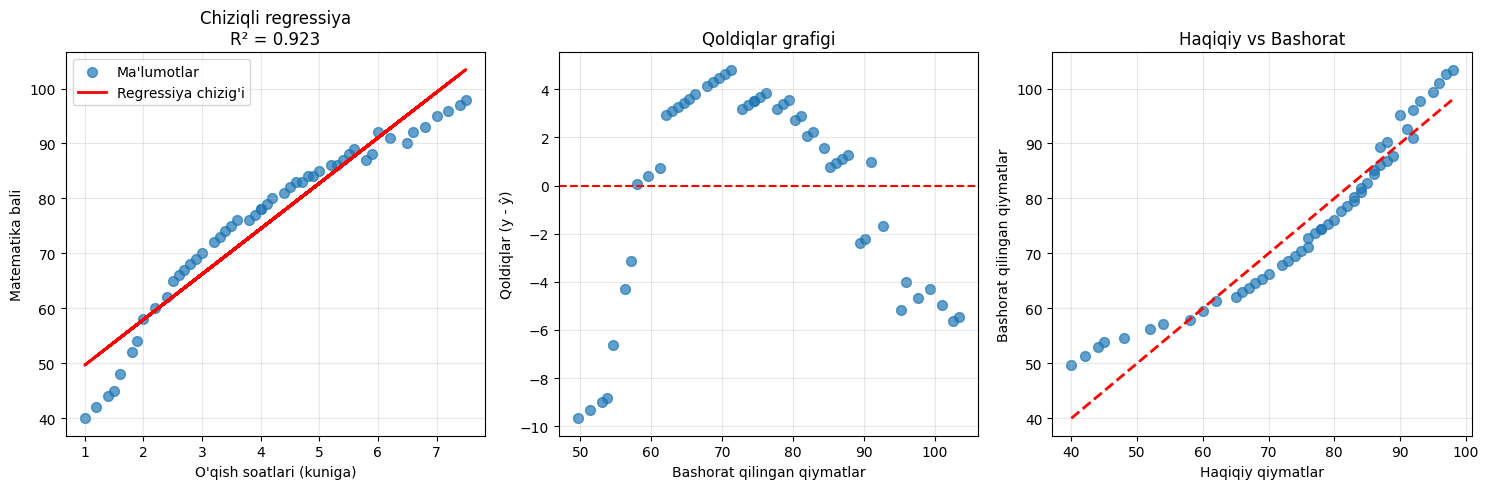

In [11]:
# Regressiya modelini vizualizatsiya qilish
plt.figure(figsize=(15, 5))

# 1. Regressiya chizig'i
plt.subplot(1, 3, 1)
plt.scatter(study_hours, math_score, alpha=0.7, s=50, label='Ma\'lumotlar')
plt.plot(study_hours, y_pred, color='red', linewidth=2, label=f'Regressiya chizig\'i')
plt.xlabel('O\'qish soatlari (kuniga)')
plt.ylabel('Matematika bali')
plt.title(f'Chiziqli regressiya\nR² = {r2:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Residuallar (qoldiqlar)
plt.subplot(1, 3, 2)
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.7, s=50)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Bashorat qilingan qiymatlar')
plt.ylabel('Qoldiqlar (y - ŷ)')
plt.title('Qoldiqlar grafigi')
plt.grid(True, alpha=0.3)

# 3. Haqiqiy vs Bashorat
plt.subplot(1, 3, 3)
plt.scatter(y, y_pred, alpha=0.7, s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Haqiqiy qiymatlar')
plt.ylabel('Bashorat qilingan qiymatlar')
plt.title('Haqiqiy vs Bashorat')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Qo'lda regressiya koeffitsiyentlarini hisoblash
print("🧮 QO'LDA REGRESSIYA KOEFFITSIYENTLARI:")
print("=" * 45)

# Asosiy statistikalar
x_vals = study_hours.values
y_vals = math_score.values

n = len(x_vals)
x_mean = np.mean(x_vals)
y_mean = np.mean(y_vals)

print(f"📊 Asosiy ma'lumotlar:")
print(f"   n = {n}")
print(f"   x̄ = {x_mean:.3f}")
print(f"   ȳ = {y_mean:.3f}")

# Og'ish koeffitsiyenti (a)
numerator = np.sum((x_vals - x_mean) * (y_vals - y_mean))
denominator = np.sum((x_vals - x_mean)**2)
a_manual = numerator / denominator

# Kesishma nuqtasi (b)
b_manual = y_mean - a_manual * x_mean

print(f"\n🧮 Hisoblash jarayoni:")
print(f"   Σ(xi - x̄)(yi - ȳ) = {numerator:.3f}")
print(f"   Σ(xi - x̄)² = {denominator:.3f}")
print(f"   a = {numerator:.3f} / {denominator:.3f} = {a_manual:.3f}")
print(f"   b = {y_mean:.3f} - {a_manual:.3f} × {x_mean:.3f} = {b_manual:.3f}")

print(f"\n✅ Tekshirish:")
print(f"   Qo'lda: a = {a_manual:.3f}, b = {b_manual:.3f}")
print(f"   sklearn: a = {a:.3f}, b = {b:.3f}")

# R² ni qo'lda hisoblash
y_pred_manual = a_manual * x_vals + b_manual
ss_res = np.sum((y_vals - y_pred_manual)**2)  # Qoldiq kvadratlari yig'indisi
ss_tot = np.sum((y_vals - y_mean)**2)         # Umumiy kvadratlari yig'indisi
r2_manual = 1 - (ss_res / ss_tot)

print(f"\n📊 R² hisoblash:")
print(f"   SS_res = {ss_res:.3f}")
print(f"   SS_tot = {ss_tot:.3f}")
print(f"   R² = 1 - ({ss_res:.3f} / {ss_tot:.3f}) = {r2_manual:.3f}")
print(f"   sklearn R²: {r2:.3f}")

🧮 QO'LDA REGRESSIYA KOEFFITSIYENTLARI:
📊 Asosiy ma'lumotlar:
   n = 50
   x̄ = 4.146
   ȳ = 75.700

🧮 Hisoblash jarayoni:
   Σ(xi - x̄)(yi - ȳ) = 1310.090
   Σ(xi - x̄)² = 158.344
   a = 1310.090 / 158.344 = 8.274
   b = 75.700 - 8.274 × 4.146 = 41.397

✅ Tekshirish:
   Qo'lda: a = 8.274, b = 41.397
   sklearn: a = 8.274, b = 41.397

📊 R² hisoblash:
   SS_res = 903.228
   SS_tot = 11742.500
   R² = 1 - (903.228 / 11742.500) = 0.923
   sklearn R²: 0.923


## 🏠 5. AMALIY MISOL: UY NARXLARINI BASHORAT QILISH

In [17]:
# Uy narxlari ma'lumotlarini yuklash va tahlil qilish
house_data = pd.read_csv('datasets/house_prices.csv')

In [18]:
house_data.head()

,house_id,size_sqm,bedrooms,bathrooms,age_years,distance_center_km,price_usd
0,1,85,2,1,5,8.5,120000
1,2,120,3,2,2,6.2,180000
2,3,65,1,1,15,12.0,85000
3,4,150,4,3,1,4.5,250000
4,5,95,2,2,8,9.1,135000


In [19]:
house_data.describe()

,house_id,size_sqm,bedrooms,bathrooms,age_years,distance_center_km,price_usd
count,50.00000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,116.00000,2.800000,2.040000,6.300000,7.552000,180400.000000
std,14.57738,38.90753,1.069045,0.902604,5.932443,3.375436,81902.380918
min,1.00000,55.00000,1.000000,1.000000,1.000000,2.500000,65000.000000
25%,13.25000,85.25000,2.000000,1.000000,2.000000,4.875000,120000.000000
50%,25.50000,111.00000,3.000000,2.000000,4.000000,7.100000,163500.000000
75%,37.75000,144.25000,3.750000,3.000000,8.000000,9.175000,233750.000000
max,50.00000,200.00000,5.000000,4.000000,25.000000,16.500000,380000.000000


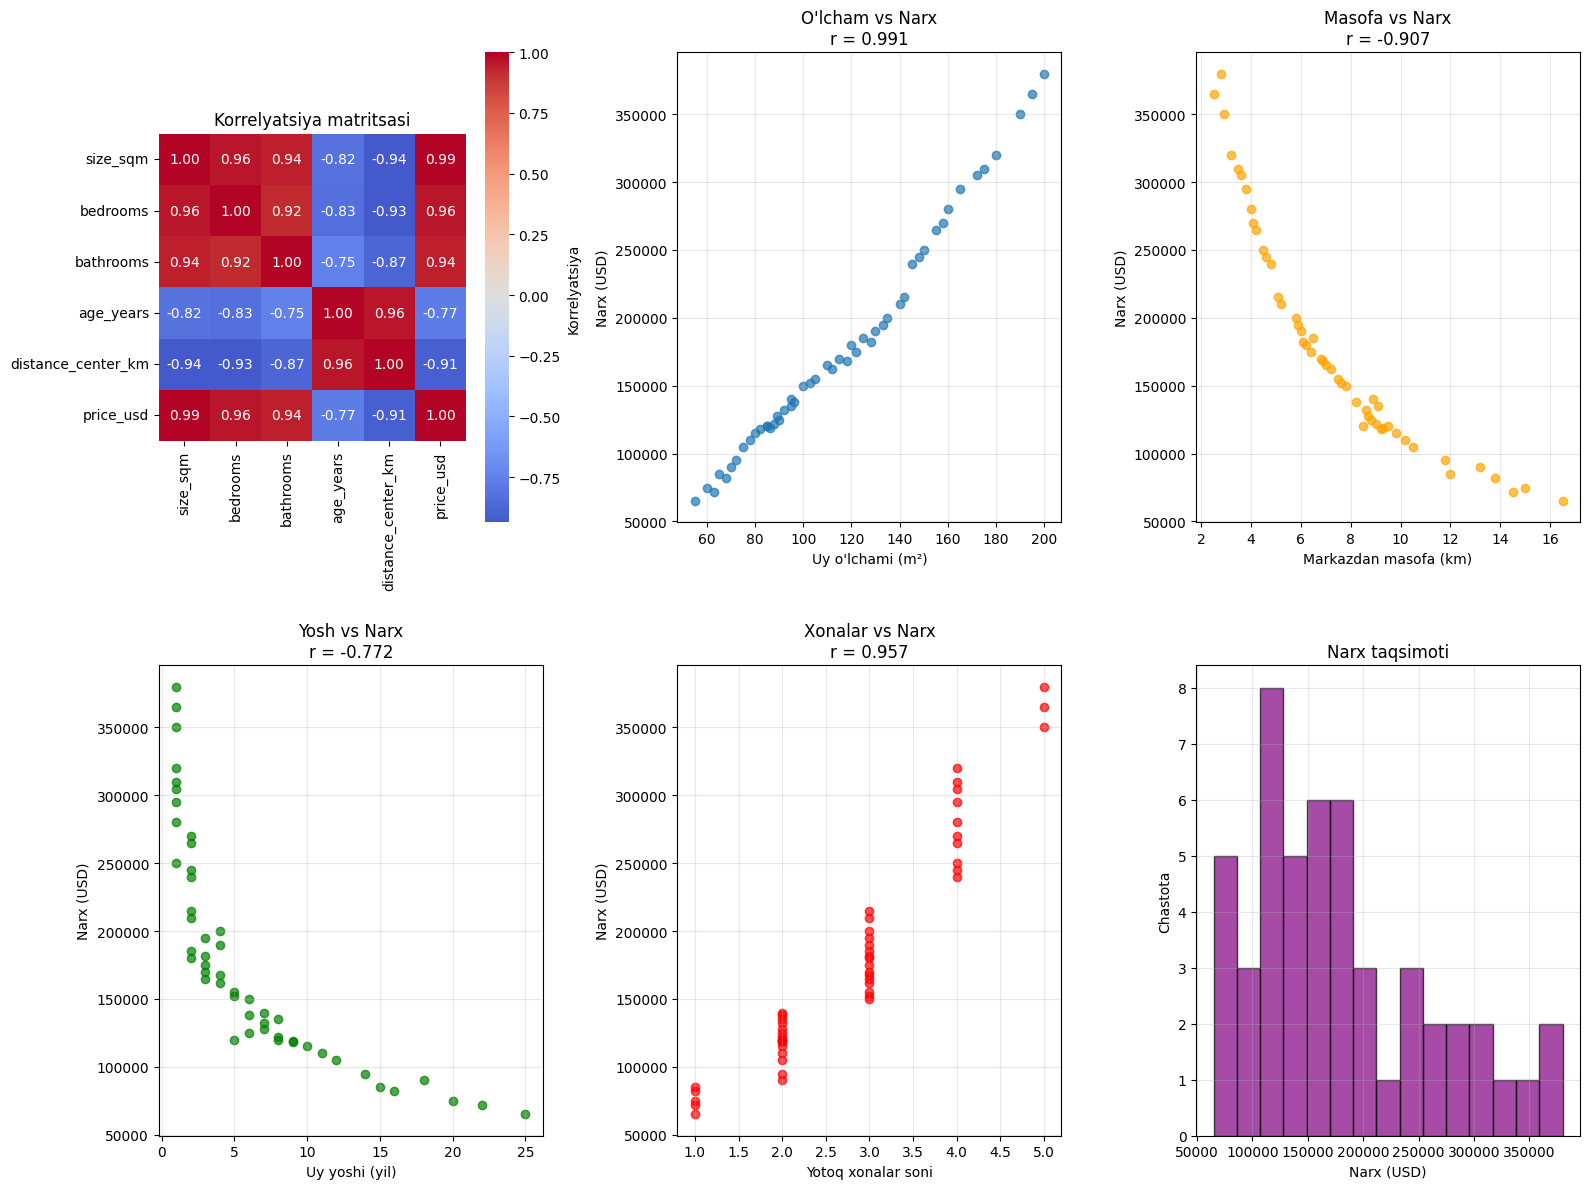


📊 NARX BILAN ENG KUCHLI KORRELYATSIYALAR:
   size_sqm            :  0.991
   bedrooms            :  0.957
   bathrooms           :  0.943
   distance_center_km  : -0.907
   age_years           : -0.772


In [20]:
# Uy narxi va turli xususiyatlar orasidagi korrelyatsiya
plt.figure(figsize=(16, 12))

# Korrelyatsiya matritsasi
plt.subplot(2, 3, 1)
numeric_cols = ['size_sqm', 'bedrooms', 'bathrooms', 'age_years', 'distance_center_km', 'price_usd']
corr_matrix = house_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'label': 'Korrelyatsiya'})
plt.title('Korrelyatsiya matritsasi')

# Uy o'lchami vs Narx
plt.subplot(2, 3, 2)
plt.scatter(house_data['size_sqm'], house_data['price_usd'], alpha=0.7)
corr_size = house_data['size_sqm'].corr(house_data['price_usd'])
plt.xlabel('Uy o\'lchami (m²)')
plt.ylabel('Narx (USD)')
plt.title(f'O\'lcham vs Narx\nr = {corr_size:.3f}')
plt.grid(True, alpha=0.3)

# Markazdan masofa vs Narx
plt.subplot(2, 3, 3)
plt.scatter(house_data['distance_center_km'], house_data['price_usd'], alpha=0.7, color='orange')
corr_distance = house_data['distance_center_km'].corr(house_data['price_usd'])
plt.xlabel('Markazdan masofa (km)')
plt.ylabel('Narx (USD)')
plt.title(f'Masofa vs Narx\nr = {corr_distance:.3f}')
plt.grid(True, alpha=0.3)

# Yoshi vs Narx
plt.subplot(2, 3, 4)
plt.scatter(house_data['age_years'], house_data['price_usd'], alpha=0.7, color='green')
corr_age = house_data['age_years'].corr(house_data['price_usd'])
plt.xlabel('Uy yoshi (yil)')
plt.ylabel('Narx (USD)')
plt.title(f'Yosh vs Narx\nr = {corr_age:.3f}')
plt.grid(True, alpha=0.3)

# Xonalar soni vs Narx
plt.subplot(2, 3, 5)
plt.scatter(house_data['bedrooms'], house_data['price_usd'], alpha=0.7, color='red')
corr_bedrooms = house_data['bedrooms'].corr(house_data['price_usd'])
plt.xlabel('Yotoq xonalar soni')
plt.ylabel('Narx (USD)')
plt.title(f'Xonalar vs Narx\nr = {corr_bedrooms:.3f}')
plt.grid(True, alpha=0.3)

# Narx taqsimoti
plt.subplot(2, 3, 6)
plt.hist(house_data['price_usd'], bins=15, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Narx (USD)')
plt.ylabel('Chastota')
plt.title('Narx taqsimoti')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Eng kuchli korrelyatsiyalar
price_corrs = corr_matrix['price_usd'].drop('price_usd').sort_values(key=abs, ascending=False)
print("\n📊 NARX BILAN ENG KUCHLI KORRELYATSIYALAR:")
print("=" * 45)
for feature, corr_val in price_corrs.items():
    print(f"   {feature:20s}: {corr_val:6.3f}")

In [22]:
# Uy o'lchami asosida narxni bashorat qilish modeli
print("🏠 UY NARXINI BASHORAT QILISH MODELI")
print("=" * 40)

# Eng kuchli bog'lanishga ega xususiyat - uy o'lchami
X_house = house_data[['size_sqm']] # -> feature
y_house = house_data['price_usd'] # -> target

# Model yaratish va o'qitish
house_model = LinearRegression()
house_model.fit(X_house, y_house)

# Model parametrlari
a_house = house_model.coef_[0]
print(f"a = {a_house=}")
b_house = house_model.intercept_
print(f"b = {b_house=}")
# Bashorat va baholash
y_house_pred = house_model.predict(X_house)
r2_house = r2_score(y_house, y_house_pred)
rmse_house = np.sqrt(mean_squared_error(y_house, y_house_pred))

print(f"📊 Model parametrlari:")
print(f"   🔢 Og'ish koeffitsiyenti: {a_house:.2f} USD/m²")
print(f"   📍 Kesishma nuqtasi: {b_house:.2f} USD")

print(f"\n📝 Regressiya tenglamasi:")
print(f"   Narx = {a_house:.2f} × O'lcham + {b_house:.2f}")
print(f"\n📊 Model sifati:")

print(f"   🎯 R²: {r2_house:.3f} ({r2_house*100:.1f}%)")
print(f"   📏 RMSE: ${rmse_house:,.0f}")

# Misollar
print(f"\n💡 AMALIY MISOLLAR:")
test_sizes = [80, 100, 120, 150, 180]
for size in test_sizes:
    predicted_price = house_model.predict([[size]])[0]
    predicted_price_manually = a_house * size + b_house
    print(f"   🏠 {size} m² uy: ${predicted_price:,.0f} (Qo'lda: ${predicted_price_manually:,.0f})")

🏠 UY NARXINI BASHORAT QILISH MODELI
a = a_house=2085.3375754961166
b = b_house=-61499.158757549536
📊 Model parametrlari:
   🔢 Og'ish koeffitsiyenti: 2085.34 USD/m²
   📍 Kesishma nuqtasi: -61499.16 USD

📝 Regressiya tenglamasi:
   Narx = 2085.34 × O'lcham + -61499.16

📊 Model sifati:
   🎯 R²: 0.981 (98.1%)
   📏 RMSE: $11,071

💡 AMALIY MISOLLAR:
   🏠 80 m² uy: $105,328 (Qo'lda: $105,328)
   🏠 100 m² uy: $147,035 (Qo'lda: $147,035)
   🏠 120 m² uy: $188,741 (Qo'lda: $188,741)
   🏠 150 m² uy: $251,301 (Qo'lda: $251,301)
   🏠 180 m² uy: $313,862 (Qo'lda: $313,862)


/opt/homebrew/Caskroom/miniforge/base/envs/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/test/lib/python3.12/site-packages/sklearn

In [23]:
# y = a*x + b 

y = a_house * 100 + b_house
print(f"\n   🏠 100 m² uy narxi: ${y}")
print(f"   Narx oralig'i: {y + rmse_house}:{y - rmse_house}")


   🏠 100 m² uy narxi: $147034.59879206214
   Narx oralig'i: 158105.11201152002:135964.08557260426


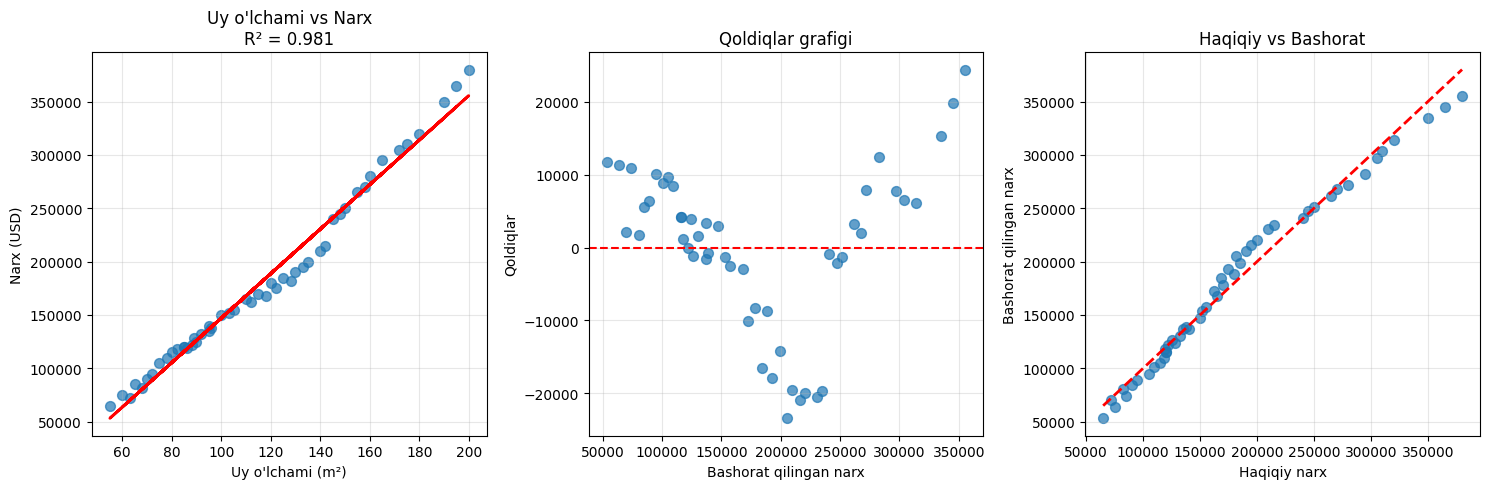


📊 MODEL XATOLIKLARI TAHLILI:
   📈 O'rtacha absolyut xatolik: $8,567
   📊 Mediana absolyut xatolik: $7,193
   📏 Maksimal xatolik: $24,432
   📉 Minimal xatolik: $11
   📊 O'rtacha absolyut foiz xatolik (MAPE): 5.2%


In [24]:
# Uy narxi modelini vizualizatsiya qilish
plt.figure(figsize=(15, 5))

# 1. Regressiya chizig'i
plt.subplot(1, 3, 1)
plt.scatter(house_data['size_sqm'], house_data['price_usd'], alpha=0.7, s=50)
plt.plot(house_data['size_sqm'], y_house_pred, color='red', linewidth=2)
plt.xlabel('Uy o\'lchami (m²)')
plt.ylabel('Narx (USD)')
plt.title(f'Uy o\'lchami vs Narx\nR² = {r2_house:.3f}')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)

# 2. Qoldiqlar
plt.subplot(1, 3, 2)
residuals_house = y_house - y_house_pred
plt.scatter(y_house_pred, residuals_house, alpha=0.7, s=50)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Bashorat qilingan narx')
plt.ylabel('Qoldiqlar')
plt.title('Qoldiqlar grafigi')
plt.ticklabel_format(style='plain')
plt.grid(True, alpha=0.3)

# 3. Bashorat vs Haqiqiy
plt.subplot(1, 3, 3)
plt.scatter(y_house, y_house_pred, alpha=0.7, s=50)
plt.plot([y_house.min(), y_house.max()], [y_house.min(), y_house.max()], 'r--', linewidth=2)
plt.xlabel('Haqiqiy narx')
plt.ylabel('Bashorat qilingan narx')
plt.title('Haqiqiy vs Bashorat')
plt.ticklabel_format(style='plain')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model xatoliklarini tahlil qilish
print(f"\n📊 MODEL XATOLIKLARI TAHLILI:")
print("=" * 35)
print(f"   📈 O'rtacha absolyut xatolik: ${np.mean(np.abs(residuals_house)):,.0f}")
print(f"   📊 Mediana absolyut xatolik: ${np.median(np.abs(residuals_house)):,.0f}")
print(f"   📏 Maksimal xatolik: ${np.max(np.abs(residuals_house)):,.0f}")
print(f"   📉 Minimal xatolik: ${np.min(np.abs(residuals_house)):,.0f}")

# Xatolik foizini hisoblash
mape = np.mean(np.abs(residuals_house / y_house)) * 100
print(f"   📊 O'rtacha absolyut foiz xatolik (MAPE): {mape:.1f}%")

## 📊 6. MODEL BAHOLASH VA TALQIN QILISH

### 🎯 R² (Aniqlash koeffitsiyenti):
- **0.7-1.0**: Juda yaxshi model
- **0.5-0.7**: Yaxshi model  
- **0.3-0.5**: O'rtacha model
- **0.0-0.3**: Zaif model

### ⚠️ Muhim ogohlantirishlar:
1. **Korrelyatsiya ≠ Sabab-oqibat**: Bog'lanish mavjudligi sabab-oqibat munosabatini bildirmaydi
2. **Outlier**lar ta'siri: Noodatiy qiymatlar korrelyatsiya va regressiyaga kuchli ta'sir qilishi mumkin
3. **Chiziqli bog'lanish**: Pearson korrelyatsiyasi faqat chiziqli bog'lanishni o'lchaydi
4. **Ekstrapoyatsiya**: Ma'lumotlar oralig'idan tashqarida bashorat qilish xavfli

In [25]:
# Korrelyatsiya va regressiya xulosa qismi
print("📋 DARS XULOSASI")
print("=" * 50)

print("🎯 BIZ NIMA O'RGANDIK:")
print("\n📊 KORRELYATSIYA:")
print(f"   • Pearson korrelyatsiyasi: chiziqli bog'lanish")
print(f"   • Spearman korrelyatsiyasi: monoton bog'lanish")
print(f"   • Korrelyatsiya koeffitsiyenti: -1 dan +1 gacha")

print("\n📈 REGRESSIYA:")
print(f"   • Oddiy chiziqli regressiya: y = ax + b")
print(f"   • Eng kichik kvadratlar usuli")
print(f"   • R² - model sifatini baholash")
print(f"   • Bashorat qilish va talqin qilish")

print("\n💡 AMALIY NATIJALAR:")
print(f"   📚 Talabalar: O'qish soatlari - Matematika bali")
print(f"      → Korrelyatsiya: {pearson_corr:.3f}")
print(f"      → R²: {r2:.3f} ({r2*100:.0f}% tushuntiriladi)")
print(f"\n   🏠 Uylar: O'lcham - Narx")
print(f"      → Korrelyatsiya: {corr_size:.3f}")
print(f"      → R²: {r2_house:.3f} ({r2_house*100:.0f}% tushuntiriladi)")
print(f"      → Har m² uchun: ${a_house:.0f} qo'shimcha")

print("\n⚠️  MUHIM ESLATMALAR:")
print(f"   • Korrelyatsiya sabab-oqibat emasligini unutmang")
print(f"   • Model faqat ma'lumotlar oralig'ida ishonchli")
print(f"   • Har doim qoldiqlarni tekshiring")
print(f"   • Outlier'larni hisobga oling")

📋 DARS XULOSASI
🎯 BIZ NIMA O'RGANDIK:

📊 KORRELYATSIYA:
   • Pearson korrelyatsiyasi: chiziqli bog'lanish
   • Spearman korrelyatsiyasi: monoton bog'lanish
   • Korrelyatsiya koeffitsiyenti: -1 dan +1 gacha

📈 REGRESSIYA:
   • Oddiy chiziqli regressiya: y = ax + b
   • Eng kichik kvadratlar usuli
   • R² - model sifatini baholash
   • Bashorat qilish va talqin qilish

💡 AMALIY NATIJALAR:
   📚 Talabalar: O'qish soatlari - Matematika bali
      → Korrelyatsiya: 0.961
      → R²: 0.923 (92% tushuntiriladi)

   🏠 Uylar: O'lcham - Narx
      → Korrelyatsiya: 0.991
      → R²: 0.981 (98% tushuntiriladi)
      → Har m² uchun: $2085 qo'shimcha

⚠️  MUHIM ESLATMALAR:
   • Korrelyatsiya sabab-oqibat emasligini unutmang
   • Model faqat ma'lumotlar oralig'ida ishonchli
   • Har doim qoldiqlarni tekshiring
   • Outlier'larni hisobga oling
